In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
world_df = pd.read_csv('worldometer_data.csv')
covid_df = pd.read_csv('covid_19_clean_complete.csv')

In [3]:
world_df.head()

,Country/Region,Continent,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop,WHO Region
0,USA,North America,3.311981e+08,5032179,NaN,162804.0,NaN,2576668.0,NaN,2292707.0,18296.0,15194.0,492.0,63139605.0,190640.0,Americas
1,Brazil,South America,2.127107e+08,2917562,NaN,98644.0,NaN,2047660.0,NaN,771258.0,8318.0,13716.0,464.0,13206188.0,62085.0,Americas
2,India,Asia,1.381345e+09,2025409,NaN,41638.0,NaN,1377384.0,NaN,606387.0,8944.0,1466.0,30.0,22149351.0,16035.0,South-EastAsia
3,Russia,Europe,1.459409e+08,871894,NaN,14606.0,NaN,676357.0,NaN,180931.0,2300.0,5974.0,100.0,29716907.0,203623.0,Europe
4,South Africa,Africa,5.938157e+07,538184,NaN,9604.0,NaN,387316.0,NaN,141264.0,539.0,9063.0,162.0,3149807.0,53044.0,Africa


In [4]:
covid_df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [5]:
print(world_df.columns.tolist())
print(covid_df.columns.tolist())

['Country/Region', 'Continent', 'Population', 'TotalCases', 'NewCases', 'TotalDeaths', 'NewDeaths', 'TotalRecovered', 'NewRecovered', 'ActiveCases', 'Serious,Critical', 'Tot Cases/1M pop', 'Deaths/1M pop', 'TotalTests', 'Tests/1M pop', 'WHO Region']
['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'WHO Region']


In [17]:
##   Checking the size of both datasets

print(world_df.shape)
print(covid_df.shape)

(209, 9)
(49068, 7)


In [18]:
## Checking for missing values in world_df

world_df.isnull().sum()

Country/Region     0
Continent          1
Population         1
TotalCases         0
TotalDeaths       21
TotalRecovered     4
ActiveCases        4
TotalTests        18
WHO Region        25
dtype: int64

In [19]:
## Checking for missing values in covid_df

covid_df.isnull().sum()

Country/Region    0
Date              0
Confirmed         0
Deaths            0
Recovered         0
Active            0
WHO Region        0
dtype: int64

In [20]:
##  Droping the columns i do not need from world_df

world_df = world_df.drop(columns=['NewCases', 'NewDeaths', 'NewRecovered', 
                                   'Serious,Critical', 'Tot Cases/1M pop', 
                                   'Deaths/1M pop', 'Tests/1M pop'])
world_df.head()

KeyError: "['NewCases', 'NewDeaths', 'NewRecovered', 'Serious,Critical', 'Tot Cases/1M pop', 'Deaths/1M pop', 'Tests/1M pop'] not found in axis"

In [ ]:
## Droping columns i do not need from covid_df

covid_df = covid_df.drop(columns=['Lat', 'Long', 'Province/State'])
covid_df.head()

In [ ]:
##  Converting the Date column to proper date format

covid_df['Date'] = pd.to_datetime(covid_df['Date'])
covid_df.head()

In [ ]:
## Done with the cleaning
## Now it is time for analysing

In [ ]:
## Top 10 countries with most cases

top_cases = world_df.groupby('Country/Region')['TotalCases'].sum().sort_values(ascending=False).head(10)
print(top_cases)

In [ ]:
## Top 10 countries with most deaths

top_deaths = world_df.groupby('Country/Region')['TotalDeaths'].sum().sort_values(ascending=False).head(10)
print(top_deaths)

In [ ]:
##  Which continent was most affected

continent_cases = world_df.groupby('Continent')['TotalCases'].sum().sort_values(ascending=False)
print(continent_cases)

In [ ]:
## The total worldwide cases deaths and recoveries

print(f"Total Cases: {world_df['TotalCases'].sum():,}")
print(f"Total Deaths: {world_df['TotalDeaths'].sum():,}")
print(f"Total Recovered: {world_df['TotalRecovered'].sum():,}")

In [ ]:
## To know  Hww cases grew over time

time_series = covid_df.groupby('Date')['Confirmed'].sum()
print(time_series)

In [ ]:
##  Death rate per country

world_df['Death_Rate'] = (world_df['TotalDeaths'] / world_df['TotalCases']) * 100
death_rate = world_df[['Country/Region', 'Death_Rate']].sort_values('Death_Rate', ascending=False).head(10)
print(death_rate)

In [ ]:
## Time for Visualization

In [ ]:
## Top 10 countries with most cases (Bar Chart)

plt.figure(figsize=(12,6))
top_cases.plot(kind='bar', color='steelblue')
plt.title('Top 10 Countries with Most COVID-19 Cases')
plt.xlabel('Country')
plt.ylabel('Total Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
## Top 10 countries with most deaths (Bar Chart)

plt.figure(figsize=(12,6))
top_deaths.plot(kind='bar', color='red')
plt.title('Top 10 Countries with Most Deaths')
plt.xlabel('Country')
plt.ylabel('Total Deaths')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
## Cases by Continent (Pie Chart)

plt.figure(figsize=(8,8))
continent_cases.plot(kind='pie', autopct='%1.1f%%')
plt.title('COVID-19 Cases by Continent')
plt.ylabel('')
plt.show()

In [ ]:
## Cases over time (Line Chart)

plt.figure(figsize=(12,6))
time_series.plot(kind='line', color='green')
plt.title('COVID-19 Cases Growth Over Time')
plt.xlabel('Date')
plt.ylabel('Total Confirmed Cases')
plt.tight_layout()
plt.show()

In [21]:
world_df.to_csv('world_covid_cleaned.csv', index=False)
covid_df.to_csv('covid_timeseries_cleaned.csv', index=False)

In [22]:
import os
files = os.listdir('C:\\Users\\HP')
print([f for f in files if 'covid' in f.lower()])

['covid_19_clean_complete.csv', 'covid_analysis.ipynb', 'covid_timeseries_cleaned.csv', 'world_covid_cleaned.csv']


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

world_df = pd.read_csv('worldometer_data.csv')
covid_df = pd.read_csv('covid_19_clean_complete.csv')
covid_df['Date'] = pd.to_datetime(covid_df['Date'])
covid_df['Month'] = covid_df['Date'].dt.month
covid_df['Year'] = covid_df['Date'].dt.year
print('Data loaded successfully')
print(world_df.shape)
print(covid_df.shape)

Data loaded successfully
(209, 16)
(49068, 12)


In [24]:
##  Death Rate Per Country

world_df['Death_Rate'] = (world_df['TotalDeaths'] / world_df['TotalCases'] * 100).round(2)
top_death_rate = world_df[world_df['TotalCases'] > 1000].nlargest(10, 'Death_Rate')
print("=== TOP 10 COUNTRIES BY DEATH RATE ===")
print(top_death_rate[['Country/Region', 'TotalCases', 'TotalDeaths', 'Death_Rate']].to_string())

=== TOP 10 COUNTRIES BY DEATH RATE ===
    Country/Region  TotalCases  TotalDeaths  Death_Rate
131          Yemen        1768        508.0       28.73
19          France      195633      30312.0       15.49
11              UK      308134      46413.0       15.06
15           Italy      249204      35187.0       14.12
35         Belgium       71158       9859.0       13.86
103        Hungary        4597        600.0       13.05
5           Mexico      462690      50517.0       10.92
40     Netherlands       56982       6153.0       10.80
9            Spain      354530      28500.0        8.04
23          Canada      118561       8966.0        7.56


In [25]:
##  Recovery Rate Analysis

world_df['Recovery_Rate'] = (world_df['TotalRecovered'] / world_df['TotalCases'] * 100).round(2)
top_recovery = world_df[world_df['TotalCases'] > 1000].nlargest(10, 'Recovery_Rate')
print("=== TOP 10 COUNTRIES BY RECOVERY RATE ===")
print(top_recovery[['Country/Region', 'TotalCases', 'TotalRecovered', 'Recovery_Rate']].to_string())

=== TOP 10 COUNTRIES BY RECOVERY RATE ===
    Country/Region  TotalCases  TotalRecovered  Recovery_Rate
133    New Zealand        1569          1524.0          97.13
24           Qatar      112092        108831.0          97.09
83        Malaysia        9038          8713.0          96.40
137         Jordan        1232          1171.0          95.05
97        Djibouti        5330          5057.0          94.88
129        Iceland        1930          1825.0          94.56
110       Thailand        3330          3148.0          94.53
81          Norway        9468          8857.0          93.55
72        S. Korea       14519         13543.0          93.28
47         Bahrain       42889         39945.0          93.14


In [26]:
##   Active Cases Analysis

world_df['Active_Cases'] = world_df['TotalCases'] - world_df['TotalDeaths'] - world_df['TotalRecovered']
top_active = world_df.nlargest(10, 'Active_Cases')
print("=== TOP 10 COUNTRIES BY ACTIVE CASES ===")
print(top_active[['Country/Region', 'TotalCases', 'Active_Cases']].to_string())

=== TOP 10 COUNTRIES BY ACTIVE CASES ===
   Country/Region  TotalCases  Active_Cases
0             USA     5032179     2292707.0
1          Brazil     2917562      771258.0
2           India     2025409      606387.0
3          Russia      871894      180931.0
8        Colombia      357710      153416.0
4    South Africa      538184      141264.0
6            Peru      455409      124648.0
17      Argentina      228195      124092.0
5          Mexico      462690      103325.0
14     Bangladesh      249651      102521.0


In [27]:
##   Continental Breakdown

continent_stats = world_df.groupby('Continent').agg(
    Total_Cases=('TotalCases', 'sum'),
    Total_Deaths=('TotalDeaths', 'sum'),
    Total_Recovered=('TotalRecovered', 'sum')
).round(2)
continent_stats['Death_Rate'] = (continent_stats['Total_Deaths'] / continent_stats['Total_Cases'] * 100).round(2)
print("=== CONTINENTAL BREAKDOWN ===")
print(continent_stats.sort_values('Total_Cases', ascending=False).to_string())

=== CONTINENTAL BREAKDOWN ===
                   Total_Cases  Total_Deaths  Total_Recovered  Death_Rate
Continent                                                                
North America          5919209      229855.0        3151678.0        3.88
Asia                   4689794      100627.0        3508170.0        2.15
South America          4543273      154885.0        3116150.0        3.41
Europe                 2982576      205232.0        1587302.0        6.88
Africa                 1011867       22114.0         693620.0        2.19
Australia/Oceania        21735         281.0          12620.0        1.29


In [28]:
##  Weekly Growth Rate

weekly = covid_df.groupby(['Year', 'Month'])['Confirmed'].sum().reset_index()
weekly['Growth_Rate'] = weekly['Confirmed'].pct_change() * 100
print("=== MONTHLY CASE GROWTH RATE ===")
print(weekly.to_string())

=== MONTHLY CASE GROWTH RATE ===
   Year  Month  Confirmed  Growth_Rate
0  2020      1      38534          NaN
1  2020      2    1663437  4216.803343
2  2020      3    9002815   441.217672
3  2020      4   63391662   604.131563
4  2020      5  144990399   128.721561
5  2020      6  246525787    70.029042
6  2020      7  362895848    47.204012


In [29]:
##  Global Summary Statistics

print("=== GLOBAL SUMMARY ===")
print(f"Total Countries Affected: {world_df['Country/Region'].nunique()}")
print(f"Total Cases Worldwide: {world_df['TotalCases'].sum():,.0f}")
print(f"Total Deaths Worldwide: {world_df['TotalDeaths'].sum():,.0f}")
print(f"Total Recovered Worldwide: {world_df['TotalRecovered'].sum():,.0f}")
print(f"Global Death Rate: {(world_df['TotalDeaths'].sum() / world_df['TotalCases'].sum() * 100):.2f}%")
print(f"Global Recovery Rate: {(world_df['TotalRecovered'].sum() / world_df['TotalCases'].sum() * 100):.2f}%")

=== GLOBAL SUMMARY ===
Total Countries Affected: 209
Total Cases Worldwide: 19,169,166
Total Deaths Worldwide: 713,007
Total Recovered Worldwide: 12,070,191
Global Death Rate: 3.72%
Global Recovery Rate: 62.97%


In [30]:
## Visualization

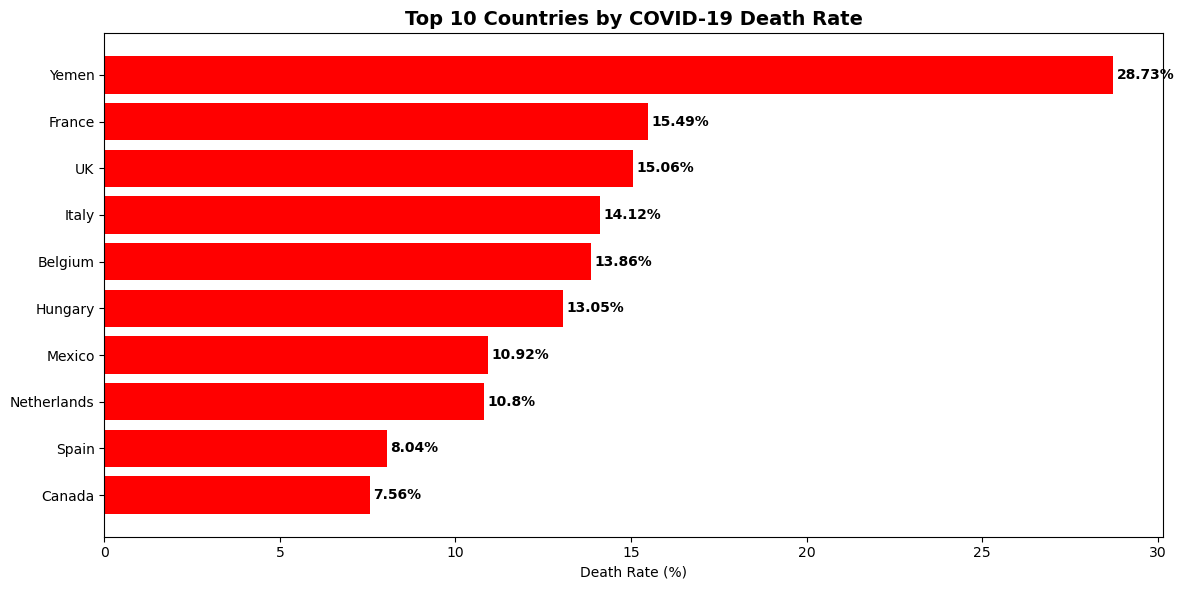

In [31]:
##Death Rate by Country

plt.figure(figsize=(12,6))
top_death_rate_sorted = top_death_rate.sort_values('Death_Rate')
plt.barh(top_death_rate_sorted['Country/Region'], top_death_rate_sorted['Death_Rate'], color='red')
plt.title('Top 10 Countries by COVID-19 Death Rate', fontsize=14, fontweight='bold')
plt.xlabel('Death Rate (%)')
for i, v in enumerate(top_death_rate_sorted['Death_Rate']):
    plt.text(v+0.1, i, f'{v}%', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

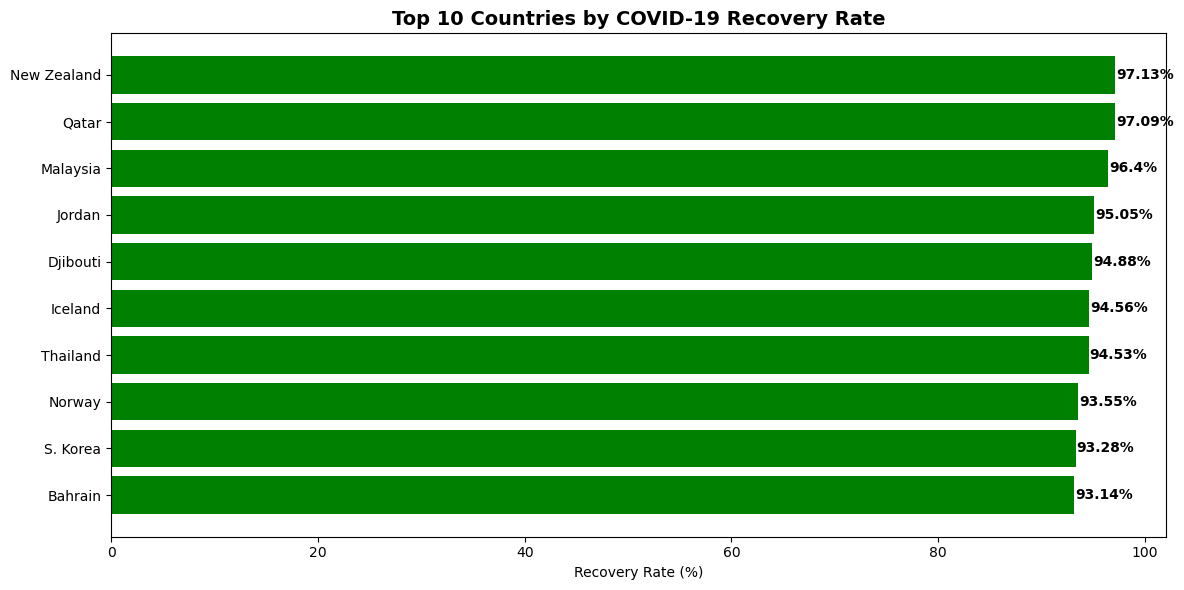

In [32]:
##  Recovery Rate by Country

plt.figure(figsize=(12,6))
top_recovery_sorted = top_recovery.sort_values('Recovery_Rate')
plt.barh(top_recovery_sorted['Country/Region'], top_recovery_sorted['Recovery_Rate'], color='green')
plt.title('Top 10 Countries by COVID-19 Recovery Rate', fontsize=14, fontweight='bold')
plt.xlabel('Recovery Rate (%)')
for i, v in enumerate(top_recovery_sorted['Recovery_Rate']):
    plt.text(v+0.1, i, f'{v}%', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

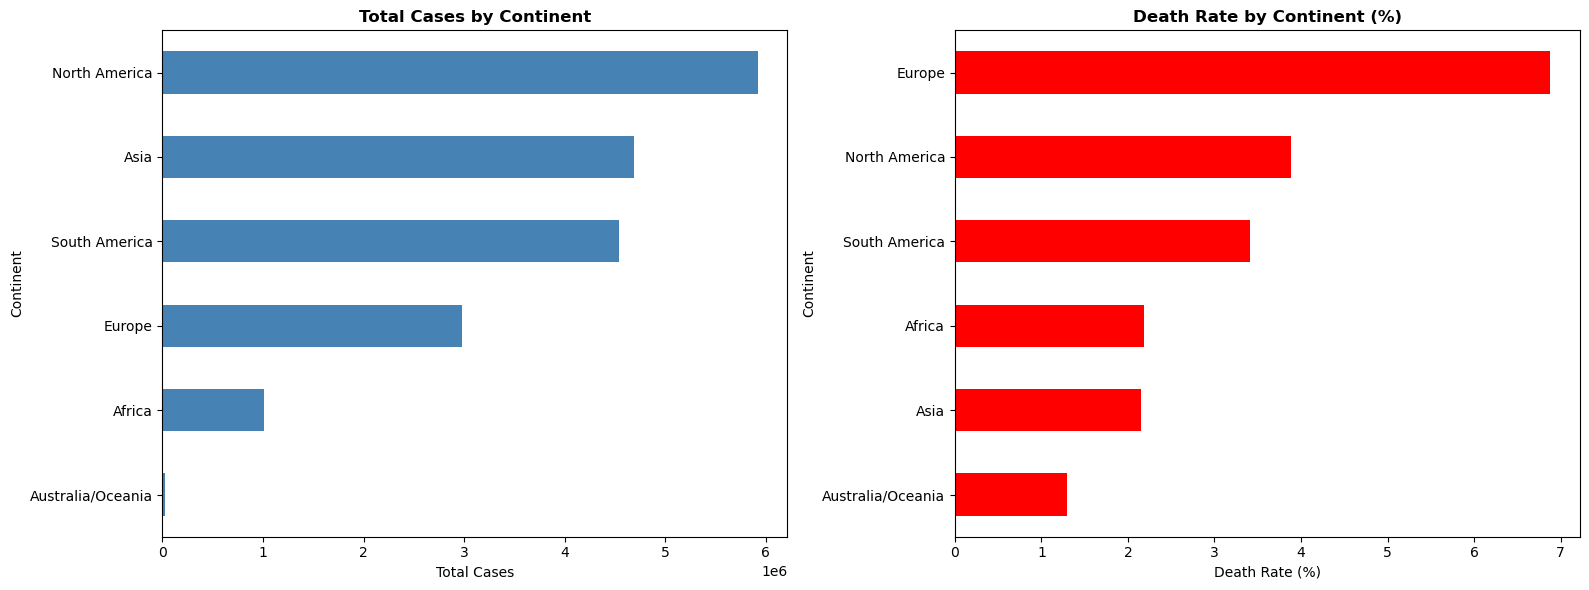

In [33]:
##  Continental Breakdown

fig, axes = plt.subplots(1, 2, figsize=(16,6))
continent_stats['Total_Cases'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Total Cases by Continent', fontweight='bold')
axes[0].set_xlabel('Total Cases')

continent_stats['Death_Rate'].sort_values().plot(kind='barh', ax=axes[1], color='red')
axes[1].set_title('Death Rate by Continent (%)', fontweight='bold')
axes[1].set_xlabel('Death Rate (%)')
plt.tight_layout()
plt.show()

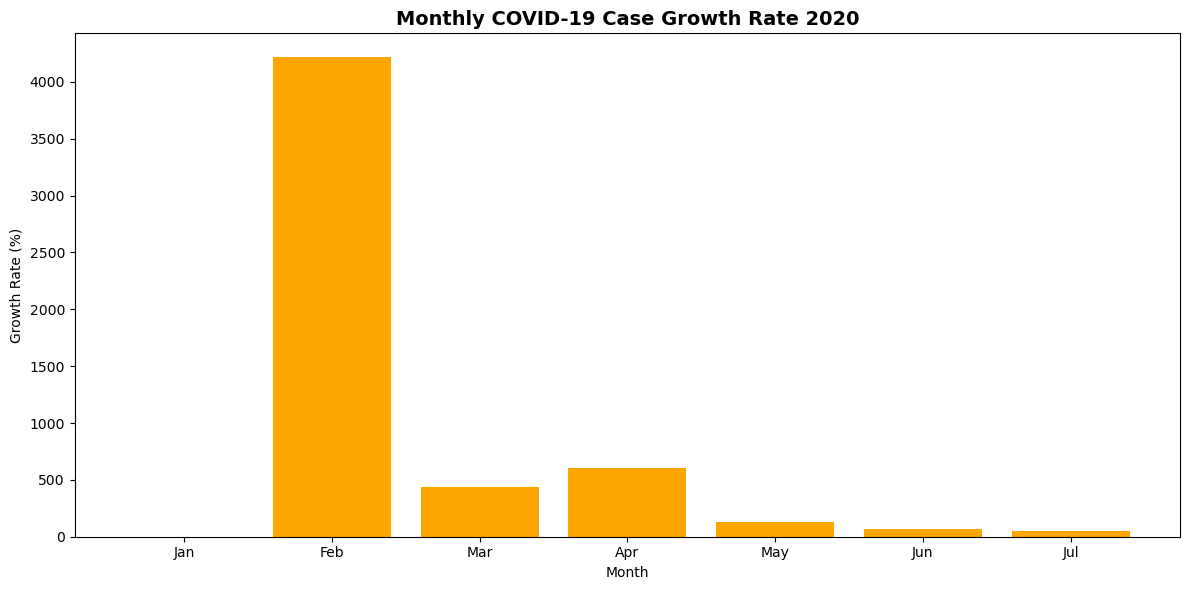

In [34]:
##   Monthly Growth Rate

plt.figure(figsize=(12,6))
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul']
plt.bar(months, weekly['Growth_Rate'].fillna(0), color='orange')
plt.title('Monthly COVID-19 Case Growth Rate 2020', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Growth Rate (%)')
plt.tight_layout()
plt.show()

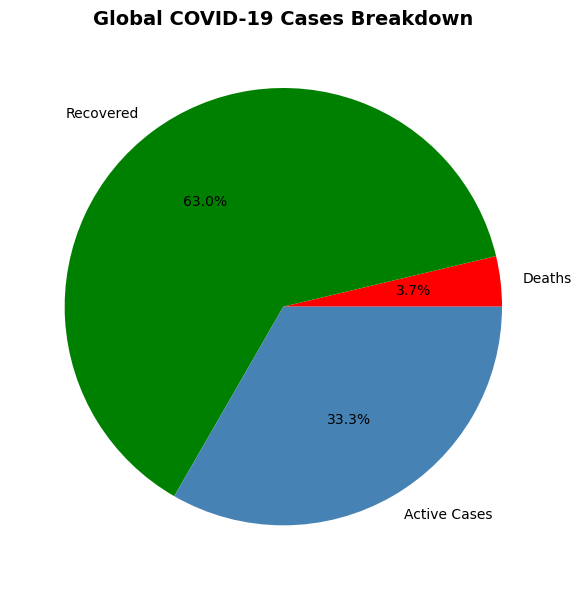

In [35]:
##  Global Summary Pie Chart

labels = ['Deaths', 'Recovered', 'Active Cases']
sizes = [713007, 12070191, 19169166-713007-12070191]
colors = ['red', 'green', 'steelblue']
plt.figure(figsize=(8,6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%')
plt.title('Global COVID-19 Cases Breakdown', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

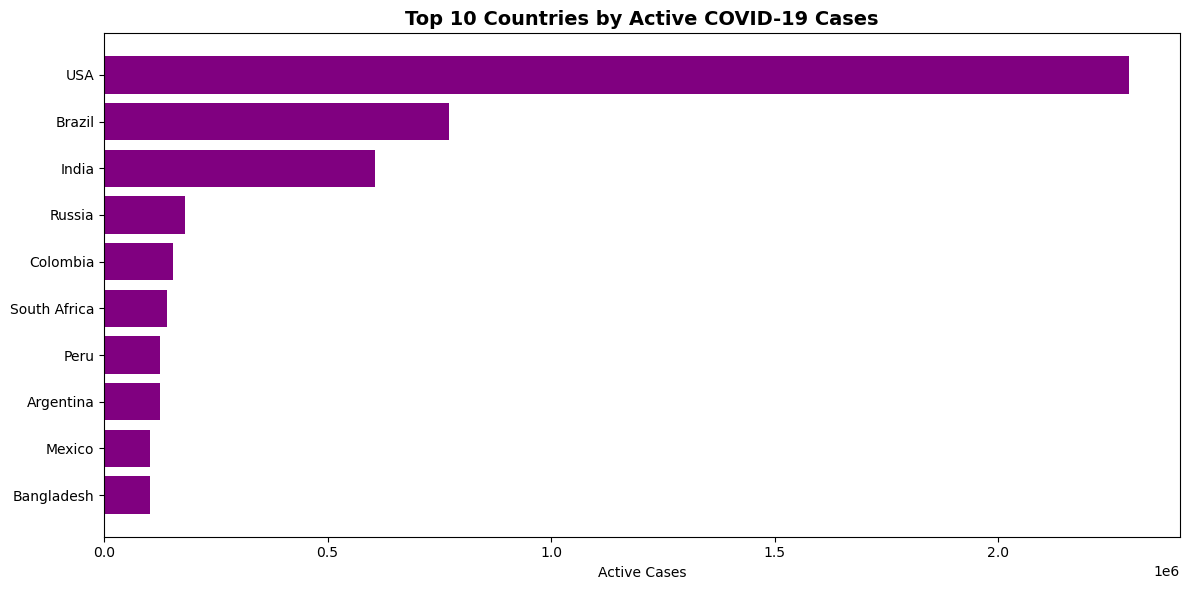

In [36]:
##  Top 10 Active Cases

plt.figure(figsize=(12,6))
top_active_sorted = top_active.sort_values('Active_Cases')
plt.barh(top_active_sorted['Country/Region'], top_active_sorted['Active_Cases'], color='purple')
plt.title('Top 10 Countries by Active COVID-19 Cases', fontsize=14, fontweight='bold')
plt.xlabel('Active Cases')
plt.tight_layout()
plt.show()

In [37]:
world_df.to_csv('world_covid_cleaned.csv', index=False)
covid_df.to_csv('covid_timeseries_cleaned.csv', index=False)
print('Files saved successfully')

Files saved successfully
